In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#this makes random numbers predictable so we all get the same plots
np.random.seed(42)

In [4]:
#how many data points we want
n = 100

# setting rules for random demographics
ages = np.random.randint(18, 90, n)
sex = np.random.choice(["Male", "Female"], n)
heart_rate = np.random.normal(80, 15, n).astype(int)
resp_rate = np.random.normal(18, 4, n).astype(int)
chief_complaints = np.random.choice(
    ["Chest Pain", "Shortness of Breath", "Abdominal Pain",
     "Headache", "Fever", "Syncope"],
    n
)

# making the dataframe
df = pd.DataFrame({
    "Age": ages,
    "Sex": sex,
    "Heart_Rate": heart_rate,
    "Resp_Rate": resp_rate,
    "Chief_Complaint": chief_complaints
})

df.head()

,Age,Sex,Heart_Rate,Resp_Rate,Chief_Complaint
0,69,Female,65,21,Syncope
1,32,Female,101,22,Fever
2,89,Male,79,14,Headache
3,78,Male,54,23,Chest Pain
4,38,Male,63,21,Fever


In [5]:
df.info()
df.describe()
df["Chief_Complaint"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              100 non-null    int64
 1   Sex              100 non-null    str  
 2   Heart_Rate       100 non-null    int64
 3   Resp_Rate        100 non-null    int64
 4   Chief_Complaint  100 non-null    str  
dtypes: int64(3), str(2)
memory usage: 4.0 KB


Chief_Complaint
Fever                  22
Headache               18
Chest Pain             17
Abdominal Pain         16
Shortness of Breath    14
Syncope                13
Name: count, dtype: int64

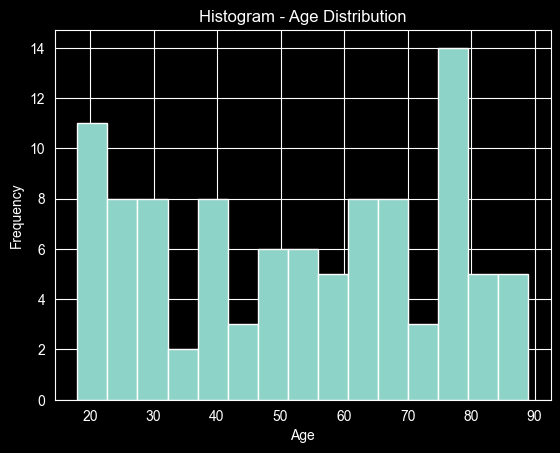

In [21]:
#histogram

plt.hist(df["Age"], bins=15)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

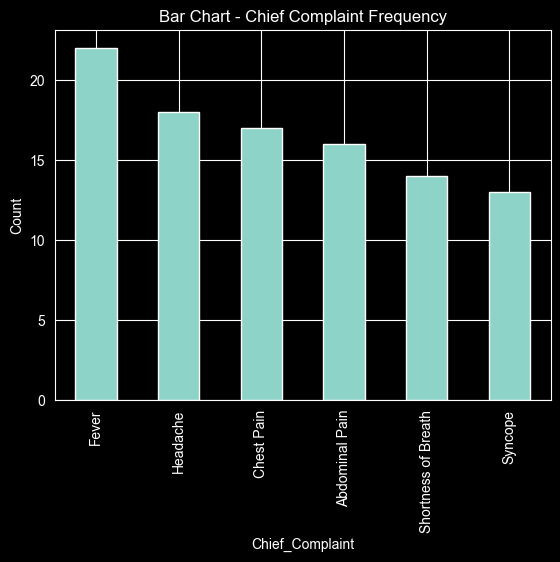

In [26]:
#bar chart

df["Chief_Complaint"].value_counts().plot(kind="bar")
plt.title("Bar Chart - Chief Complaint Frequency")
plt.ylabel("Count")
plt.show()

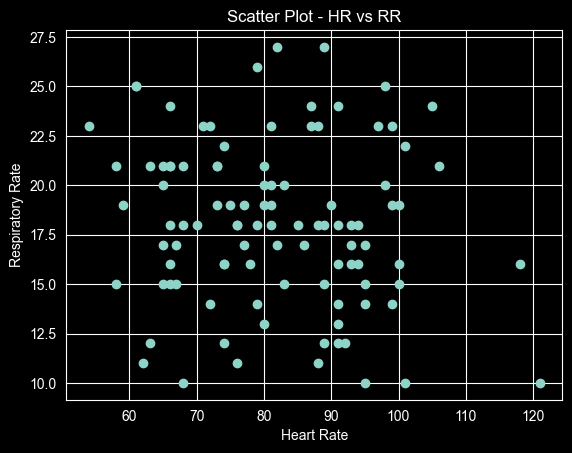

In [27]:
#scatter plot

plt.scatter(df["Heart_Rate"], df["Resp_Rate"])
plt.xlabel("Heart Rate")
plt.ylabel("Respiratory Rate")
plt.title("Scatter Plot - HR vs RR")
plt.show()

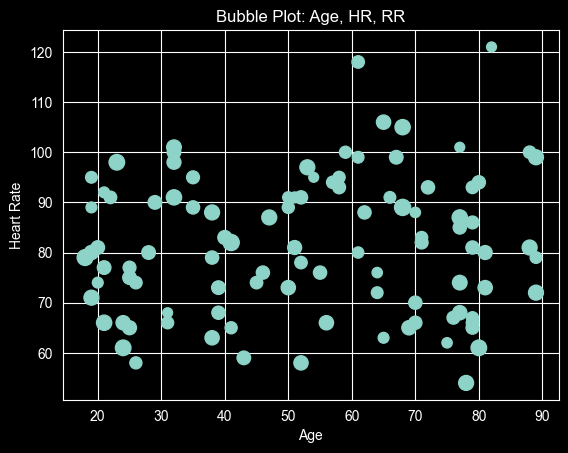

In [13]:
#bubble plot

plt.scatter(df["Age"],
            df["Heart_Rate"],
            s=df["Resp_Rate"]*5)

plt.xlabel("Age")
plt.ylabel("Heart Rate")
plt.title("Bubble Plot: Age, HR, RR")
plt.show()

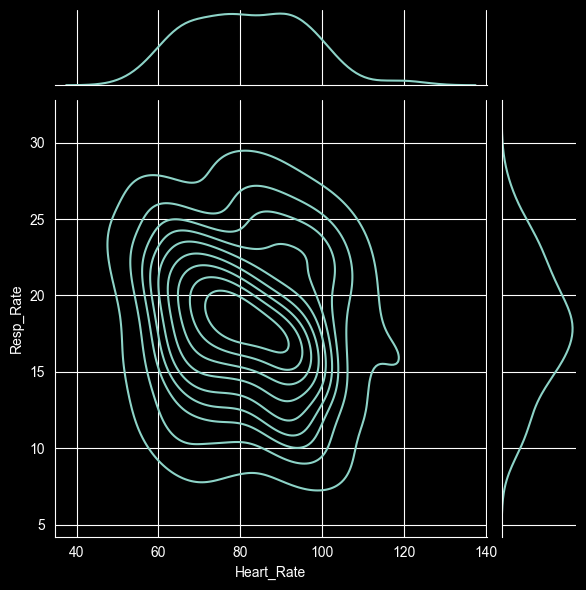

In [8]:
#scatterplot with density overlay

sns.jointplot(x="Heart_Rate", y="Resp_Rate", data=df, kind="kde")
plt.show()

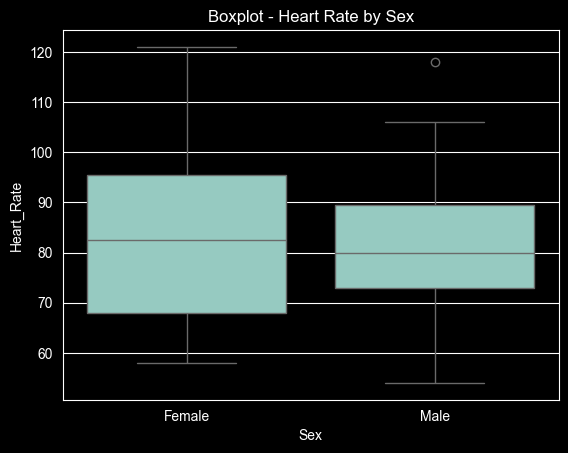

In [29]:
#boxplot

sns.boxplot(x="Sex", y="Heart_Rate", data=df)
plt.title("Boxplot - Heart Rate by Sex")
plt.show()

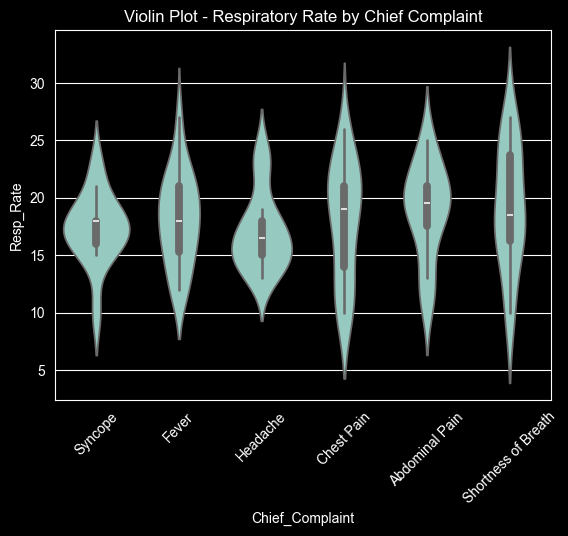

In [30]:
#violin plot

sns.violinplot(x="Chief_Complaint", y="Resp_Rate", data=df)
plt.xticks(rotation=45)
plt.title("Violin Plot - Respiratory Rate by Chief Complaint")
plt.show()

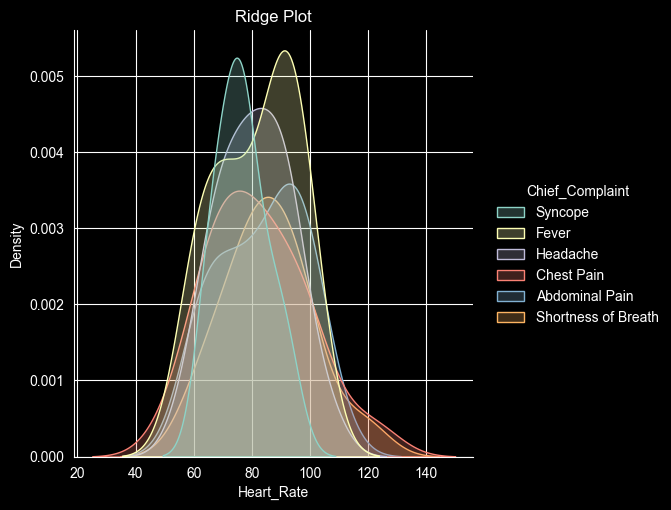

In [16]:
#ridge plot

import seaborn as sns

sns.displot(df, x="Heart_Rate",
            hue="Chief_Complaint",
            kind="kde",
            fill=True)

plt.title("Ridge Plot")
plt.show()

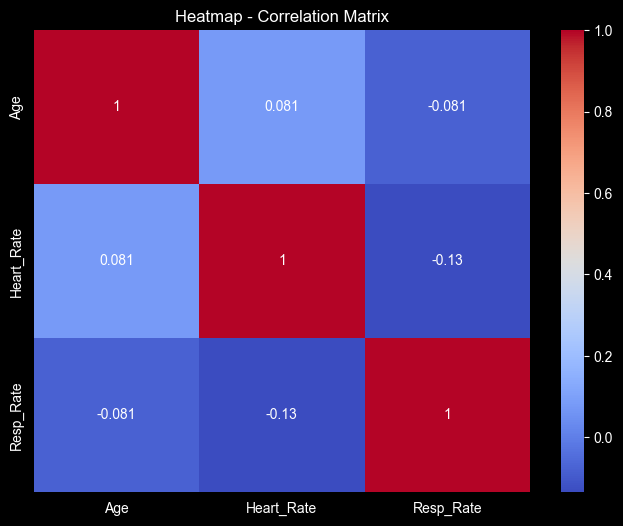

In [31]:
#heatmap - correlation matrix

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Heatmap - Correlation Matrix")
plt.show()

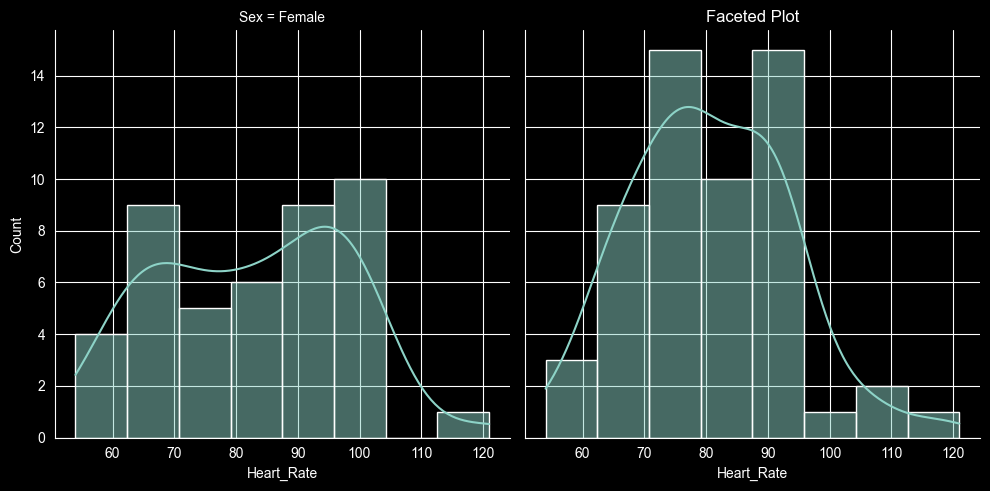

In [32]:
#faceted plot

sns.displot(data=df, x="Heart_Rate", col="Sex", kde=True)
plt.title("Faceted Plot")
plt.show()

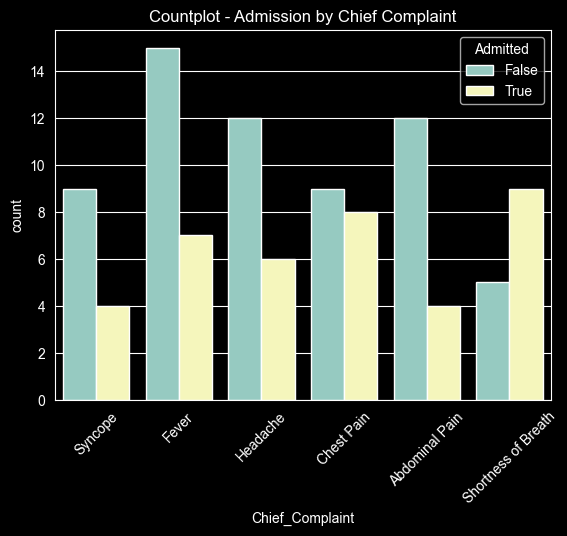

In [33]:
#this one is a paired bar plot aka countplot but it's also performing an extra step:

#it's deciding which ones are admitted via these set of rules
df["Admitted"] = (
    (df["Heart_Rate"] > 100) |
    (df["Resp_Rate"] > 22) |
    (df["Age"] > 75)
)

sns.countplot(x="Chief_Complaint", hue="Admitted", data=df)
plt.xticks(rotation=45)
plt.title("Countplot - Admission by Chief Complaint")
plt.show()

In [24]:
# Now we move into more predictive modeling and regressions. Keep in mind these are all templates for now

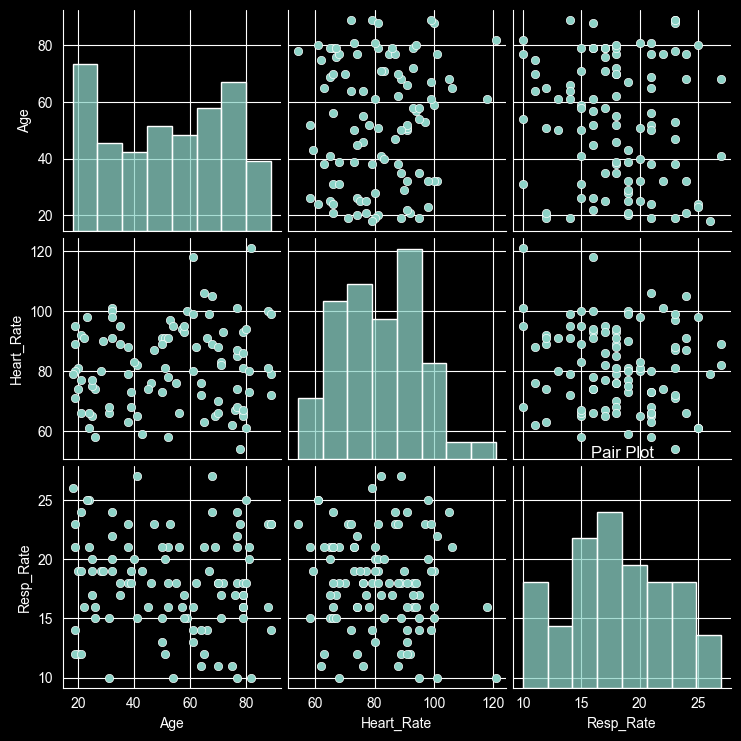

In [38]:
#pair plot - helps with a quick regression screening tool

sns.pairplot(df[["Age","Heart_Rate","Resp_Rate"]])
plt.title("Pair Plot")
plt.show()

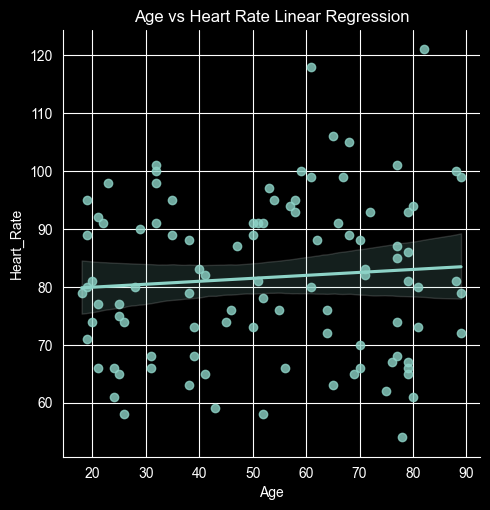

In [39]:
#simple regression

sns.lmplot(x="Age", y="Heart_Rate", data=df)
plt.title("Age vs Heart Rate Linear Regression")
plt.show()

In [19]:
data = {
    "Variable": [
        "Age > 65",
        "Tachycardia",
        "Tachypnea",
        "Male Sex",
        "Chest Pain",
        "Shortness of Breath"
    ],
    "Odds_Ratio": [2.1, 1.8, 2.5, 1.2, 1.4, 2.9],
    "CI_Lower": [1.3, 1.1, 1.6, 0.8, 0.9, 1.9],
    "CI_Upper": [3.4, 2.9, 3.9, 1.9, 2.2, 4.5]
}

forest_df = pd.DataFrame(data)
forest_df

,Variable,Odds_Ratio,CI_Lower,CI_Upper
0,Age > 65,2.1,1.3,3.4
1,Tachycardia,1.8,1.1,2.9
2,Tachypnea,2.5,1.6,3.9
3,Male Sex,1.2,0.8,1.9
4,Chest Pain,1.4,0.9,2.2
5,Shortness of Breath,2.9,1.9,4.5


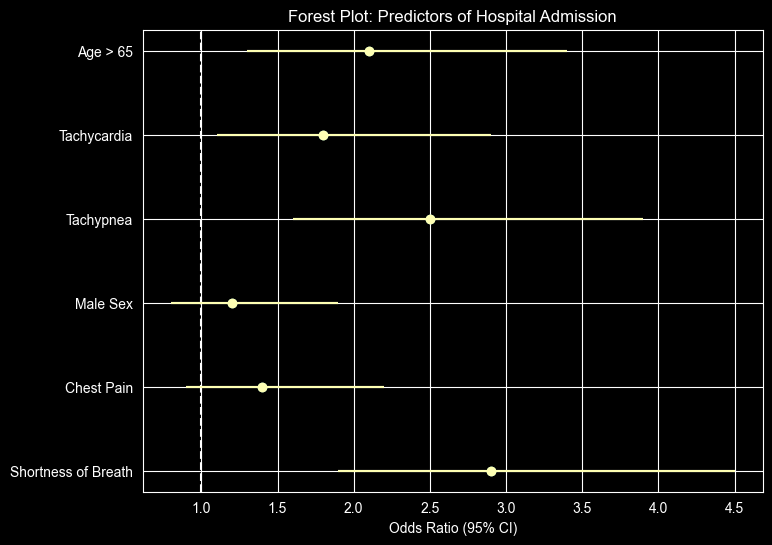

In [40]:
plt.figure(figsize=(8,6))

y_positions = range(len(forest_df))

# Plot confidence intervals
plt.hlines(y=y_positions,
           xmin=forest_df["CI_Lower"],
           xmax=forest_df["CI_Upper"])

# Plot point estimates
plt.plot(forest_df["Odds_Ratio"], y_positions, "o")

# Vertical line at OR = 1
plt.axvline(x=1, linestyle="--")

plt.yticks(y_positions, forest_df["Variable"])
plt.xlabel("Odds Ratio (95% CI)")
plt.title("Forest Plot: Predictors of Hospital Admission")

plt.gca().invert_yaxis()  # Makes top variable appear first

plt.errorbar(
    forest_df["Odds_Ratio"],
    y_positions,
    xerr=[
        forest_df["Odds_Ratio"] - forest_df["CI_Lower"],
        forest_df["CI_Upper"] - forest_df["Odds_Ratio"]
    ],
    fmt='o'
)

plt.show()

In [41]:
np.random.seed(42)

# Simulate follow-up time (in days)
df["Followup_Days"] = np.random.exponential(scale=10, size=len(df))

# Higher risk patients deteriorate faster
risk_score = (
    (df["Heart_Rate"] > 100).astype(int) +
    (df["Resp_Rate"] > 22).astype(int) +
    (df["Age"] > 75).astype(int)
)

# Convert to probability of event
event_probability = 0.2 + 0.2 * risk_score

df["Event"] = np.random.binomial(1, np.clip(event_probability, 0, 0.9))

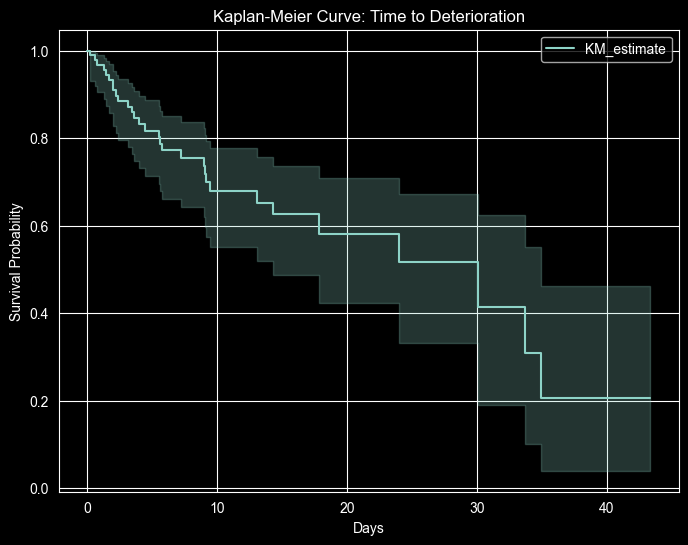

In [43]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

plt.figure(figsize=(8,6))

kmf.fit(df["Followup_Days"], event_observed=df["Event"])
kmf.plot_survival_function()

plt.title("Kaplan-Meier Curve: Time to Deterioration")
plt.xlabel("Days")
plt.ylabel("Survival Probability")
plt.show()

In [44]:
df["Tachycardia"] = df["Heart_Rate"] > 100

# Calculate mean event rate by group
interaction_data = (
    df.groupby(["Sex", "Tachycardia"])["Event"]
    .mean()
    .reset_index()
)

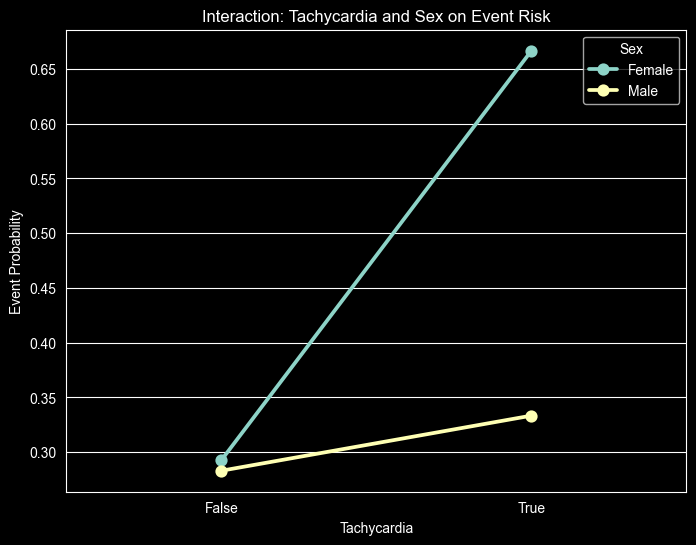

In [45]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.pointplot(
    data=interaction_data,
    x="Tachycardia",
    y="Event",
    hue="Sex"
)

plt.title("Interaction: Tachycardia and Sex on Event Risk")
plt.ylabel("Event Probability")
plt.show()